#  Cats Vs Dogs (Pretrained - Feature Extraction)

Hay 2 formas de usar una red preentrenada *feature extraction* y *fine-tuning*. 

En este *notebook* se profundiza en la tecnica *feature extraction*.

*Paths* importantes:

In [ ]:
import os

base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

Para ello se recupera la *convolutional base* del modelo *VGG16* disponible en `keras.applications`:

In [3]:
from keras.applications import VGG16

conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
conv_base.summary()

I0000 00:00:1753583547.070067  576748 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11398 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

# Forma 1: Memorizar resultados de Conv

La primera forma de la extraccion de caracteristicas consiste en pasar todas las imagenes por la capa convolucional y luego usar de forma autonoma las salidas como entrada de la capa denza. Barato y eficiente al momento de ejecutar pero no elimina la necesidad de en algun momento pasar la imagen por la red convolucional. No es apto para convinar con *data augmentation* (se puede ajustar para que si lo sea).

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512)) # Size de salida de *convolutional base*.
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150,150),
        batch_size=batch_size,
        class_mode='binary'
    )
    i=0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        features[i * batch_size : (i+1) * batch_size] = features_batch
        labels[i * batch_size : (i+1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels # Retorna las caracteristicas ya procesadas por la red convolucional.

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.


I0000 00:00:1753570967.213420  568718 service.cc:152] XLA service 0x7fa694046990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753570967.213439  568718 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-26 20:02:47.222764: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753570967.296084  568718 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-26 20:02:47.562132: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.39 = (f32[20,64,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0} %bitcast.396, f32[64,3,3,3]{3,2,1,0} %bitcast.403, f32[64]{0} %bitcast.405), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudn

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


I0000 00:00:1753570970.256947  568718 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

Los datos de entrada deben ser aplanados para ser adecuados para el clasificador denso:

In [4]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

Definir el clasificador densamente conectado:

In [5]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu',input_dim=4*4*512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(
    train_features, 
    train_labels, 
    epochs=30, 
    batch_size=20,
    validation_data=(validation_features, validation_labels))

Epoch 1/30


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.6176 - loss: 0.6598 - val_acc: 0.8310 - val_loss: 0.4447
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8104 - loss: 0.4397 - val_acc: 0.8660 - val_loss: 0.3619
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8439 - loss: 0.3726 - val_acc: 0.8850 - val_loss: 0.3212
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8680 - loss: 0.3208 - val_acc: 0.8880 - val_loss: 0.3001
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8817 - loss: 0.2930 - val_acc: 0.8550 - val_loss: 0.3328
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9044 - loss: 0.2502 - val_acc: 0.8930 - val_loss: 0.2721
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9007 - loss: 0.2462 - val_acc: 0.8850 - val_loss: 0.2688
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9073 - loss: 0.2373 - val_acc: 0.8960 - val_loss: 0.2573
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9217 -

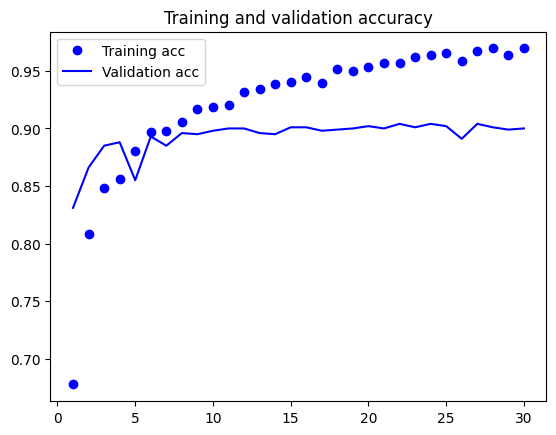

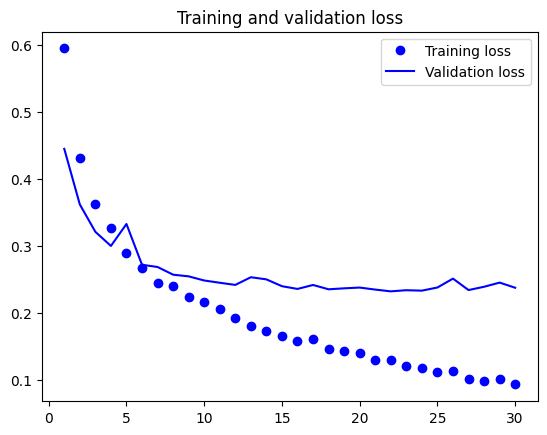

In [6]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

*loss*=$0.25$, *acc*=$0.90$ 

Respecto a la ConvNet entrenada desde cero el *loss* mejoro en $0.15$ y el *acc* mejoro en $0.10$.

El entrenamiento fue muy rapido ya que solo hubo que ajustar los valores de 2 capas densas (y una solo tiene una unidad oculta).

# Agregando Data Augmentation

El esquema anterior funciona pero tiene la contra de que no se puede usar *data augmentation* ante situaciones de *overfitting* (ya que las salidas convolucionales de las imagenes son preejecutadas y no en tiempo real).

Es mas exigente respecto a computo en tiempo real pero otra opcion es encadenar a la base convolucional el clasificador denso, todo en un mismo modelo. Asi cualquier imagen puede ser recibida.

Contraprestación, es inviable ejecutarla sin GPU, si solo se cuenta con CPU la tecnica anterior es una mejor opción.

In [4]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

Ahora hay que congelar la base convolucional para que las *features* que aprendio no sean destruidas por la inicializacion aleatoria del clasificador denso y su posterior entrenamineto.

In [5]:
print('This is the number of trainable weights '
      'before freezing the conv base:', len(model.trainable_weights))
conv_base.trainable = False
print('This is the number of trainable weights '
      'after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights before freezing the conv base: 30
This is the number of trainable weights after freezing the conv base: 4


Entrenar con *data augmentation*:

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

model.compile(
    optimizer= optimizers.RMSprop(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['acc'])

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50,
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1753583552.859635  576777 service.cc:152] XLA service 0x7f2308003e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753583552.859654  576777 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-26 23:32:32.892439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753583553.211156  576777 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-26 23:32:33.494788: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.39 = (f32[20,64,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0} %bitcast.1090, f32[64,3,3,3]{3,2,1,0} %bitcast.1097, f32[64]{0} %bitcast.1099), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

  3/100 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - acc: 0.6556 - loss: 0.6321

I0000 00:00:1753583556.358959  576777 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - acc: 0.6403 - loss: 0.6223

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - acc: 0.6407 - loss: 0.6219 - val_acc: 0.8220 - val_loss: 0.4319
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.7743 - loss: 0.4848 - val_acc: 0.8510 - val_loss: 0.3567
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.7982 - loss: 0.4491 - val_acc: 0.8650 - val_loss: 0.3281
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - acc: 0.8318 - loss: 0.3918 - val_acc: 0.8810 - val_loss: 0.3026
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.8283 - loss: 0.3850 - val_acc: 0.8830 - val_loss: 0.2915
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.8601 - loss: 0.3402 - val_acc: 0.8870 - val_loss: 0.2776
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.8495 - loss: 0.3528 - val_acc: 0.8860 - val_loss: 0.2726
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.8451 - loss: 0.3583 - val_acc: 0.8830 - val_loss: 0.2791
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s

In [9]:
model.save('./models/cats_and_dogs_small_4.h5')

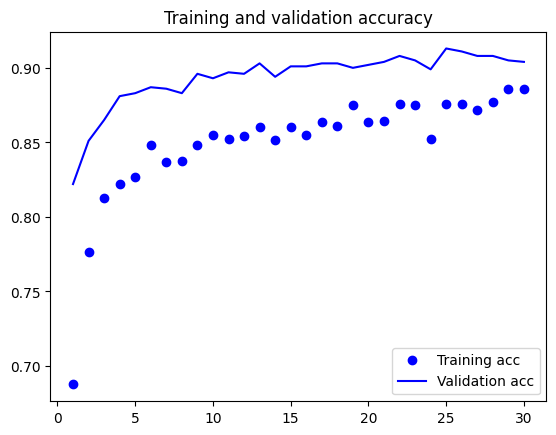

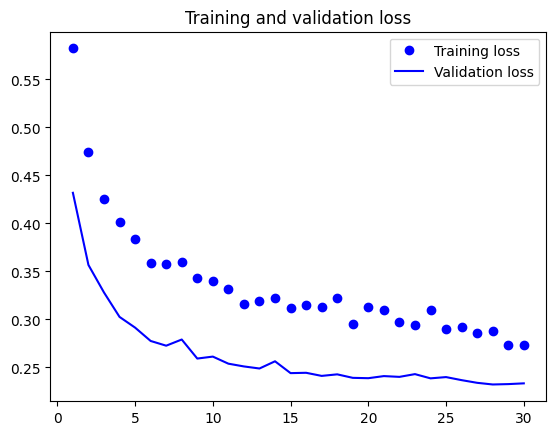

In [10]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

*loss*=$0.25$, *acc*=$0.91$ 

Respecto al metodo de memorizado de salidas el *loss* mejoro en $0.00$ y el *acc* mejoro en $0.01$.

<!-- Es irregular que en ambos casos `loss` y `acc` las metricas de validacion fueron mejores que las de train. Probablemente tenga que ver con el *data augmentation*.  -->

La curva de validacion mantiene la tendencia de la curba de train en ambos casos.

El entrenamiento tardo mucho mas que en el caso anterior, hay que considerar que aunque solo se ajusten las ultimas 2 capas aun hay que ejecutar toda la base convolucional durante el entrenamiento(es una carga significativa).

